In [1]:
import pandas as pd
import numpy as np

from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

In [2]:
raw_expresssion_not_deconvoluted=pd.read_csv("/Volumes/h30492/farkkilab2/4_CellCycle/geomx/RNA_Expression_for_Analysis/batch123_gene_expression_not_deconvoluted_harmony_batch_corr_deseq2_vst_3003.csv")

raw_expression_transposed=raw_expresssion_not_deconvoluted.T
# Make the first row the column names
raw_expression_transposed.columns = raw_expression_transposed.iloc[0]  # set first row as header
raw_expression_transposed = raw_expression_transposed[1:]  # drop the first row now used as header

# Reset the index if needed (optional)
raw_expression_transposed = raw_expression_transposed.reset_index()

# Rename 'Unnamed: 0' column to 'dcc_filename_1'
raw_expression_transposed = raw_expression_transposed.rename(columns={"index": "dcc_filename_1"})


tumor_expression_deconvoluted=pd.read_csv("/Volumes/h30492/farkkilab2/4_CellCycle/geomx/RNA_Expression_for_Analysis/tumor_gene_expression_data_new_batch_merged_1903.csv")

tumor_expression_transposed=tumor_expression_deconvoluted.T

# Make the first row the column names
tumor_expression_transposed.columns = tumor_expression_transposed.iloc[0]  # set first row as header
tumor_expression_transposed = tumor_expression_transposed[1:]  # drop the first row now used as header

# Reset the index if needed (optional)
tumor_expression_transposed = tumor_expression_transposed.reset_index()

# Rename 'Unnamed: 0' column to 'dcc_filename_1'
tumor_expression_transposed = tumor_expression_transposed.rename(columns={"index": "dcc_filename_1"})


cells_with_dcc_filenames=pd.read_csv("/Volumes/h30492/farkkilab2/4_CellCycle/geomx/Data/Transferred_ROIs/cells_with_matched_dcc_files.csv")

metadata=pd.read_csv("/Volumes/h30492/farkkilab2/9_EyeMT/Data/geomx/batch123/metadata/dcc_metadata_batch123_cleaned.csv")

# Define numerator and denominator labels
numerator_labels = ["Tumor_Ki67", "Tumor_Ki67_pRb", "Tumor_PH3"]
denominator_labels = ["Tumor", "Tumor_Ki67_pRb", "Tumor_PH3", "Tumor_Ki67", "undefined_Tumor"]

# Calculate proportion per AOI
cells_with_dcc_filenames['proportion_Ki67_pRb'] = (
    cells_with_dcc_filenames
    .groupby('dcc_filename_1')['final_label']
    .transform(lambda x: x.isin(numerator_labels).sum() / max(x.isin(denominator_labels).sum(), 1))
)

cells_with_dcc_filenames['AOI_PH3_counts']=(cells_with_dcc_filenames
    .groupby('dcc_filename_1')['final_label']
    .transform(lambda x: x.isin(["Tumor_PH3"]).sum())
)
cells_with_dcc_filenames['AOI_Ki67_counts']=(cells_with_dcc_filenames
    .groupby('dcc_filename_1')['final_label']
    .transform(lambda x: x.isin(["Tumor_Ki67"]).sum())
)
cells_with_dcc_filenames['AOI_Ki67_pRb_counts']=(cells_with_dcc_filenames
    .groupby('dcc_filename_1')['final_label']
    .transform(lambda x: x.isin(["Tumor_Ki67_pRb"]).sum())
)
# Count tumor cells per AOI
cells_with_dcc_filenames["AOI_tumor_counts"] = (
    cells_with_dcc_filenames
    .groupby('dcc_filename_1')['final_label']
    .transform(lambda x: x.isin(denominator_labels).sum())
)

cells_with_dcc_filenames["AOI_Ki67_pRb_niche_counts"] = (
    cells_with_dcc_filenames
    .groupby('dcc_filename_1')['final_label']
    .transform(lambda x: x.isin(numerator_labels).sum())
)



In [5]:
metadata = metadata.rename(columns={'dcc_filename': 'dcc_filename_1'})

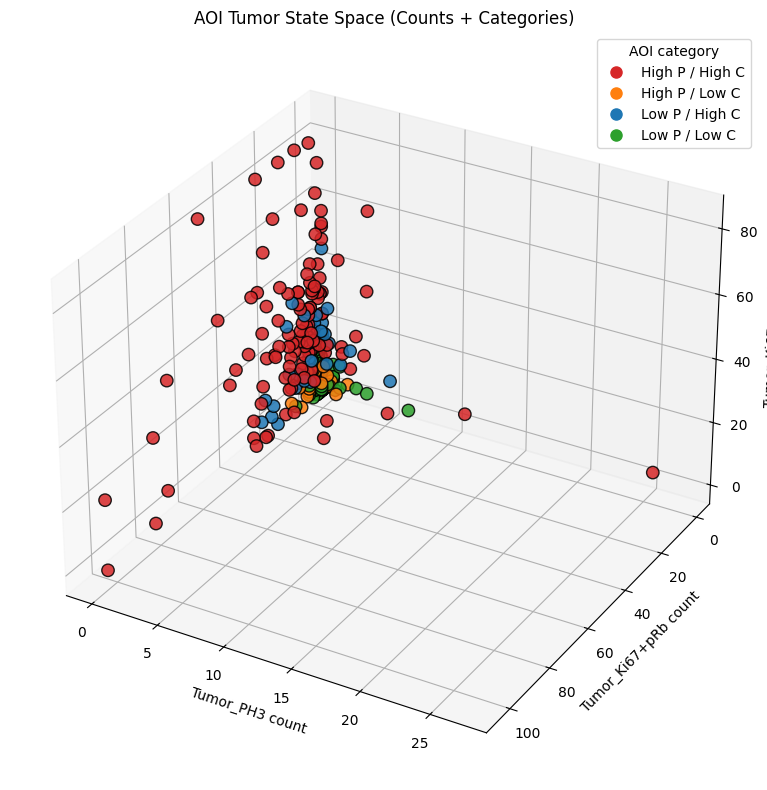

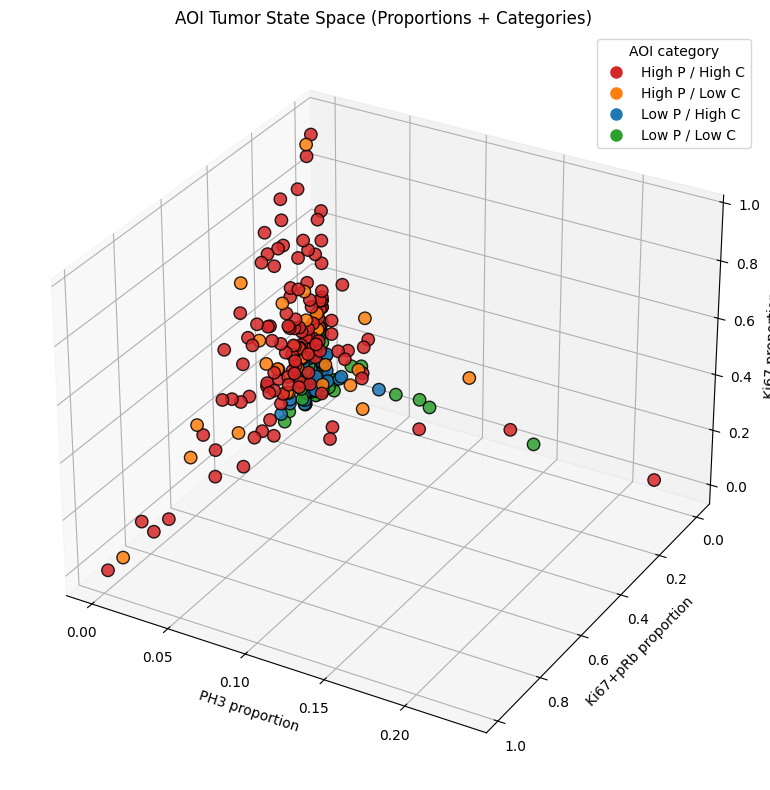

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# 1. AOI-level summary
# -----------------------------
numerator_labels = ["Tumor_Ki67", "Tumor_Ki67_pRb", "Tumor_PH3"]
denominator_labels = ["Tumor", "Tumor_Ki67_pRb", "Tumor_PH3", "Tumor_Ki67", "undefined_Tumor"]

aoi_summary = cells_with_dcc_filenames.groupby("dcc_filename_1").agg(
    Tumor_total_count=('final_label', lambda x: x.isin(denominator_labels).sum()),
    Tumor_Ki67_count=('final_label', lambda x: (x == "Tumor_Ki67").sum()),
    Tumor_Ki67_pRb_count=('final_label', lambda x: (x == "Tumor_Ki67_pRb").sum()),
    Tumor_PH3_count=('final_label', lambda x: (x == "Tumor_PH3").sum())
).reset_index()

# -----------------------------
# 2. FILTER: remove bottom 10% AOIs
# -----------------------------
low_10_threshold = aoi_summary['Tumor_total_count'].quantile(0.10)

aoi_summary = aoi_summary[
    aoi_summary['Tumor_total_count'] > low_10_threshold
].reset_index(drop=True)

# -----------------------------
# 3. Proportions
# -----------------------------
aoi_summary['Ki67_prop'] = aoi_summary['Tumor_Ki67_count'] / aoi_summary['Tumor_total_count']
aoi_summary['Ki67_pRb_prop'] = aoi_summary['Tumor_Ki67_pRb_count'] / aoi_summary['Tumor_total_count']
aoi_summary['PH3_prop'] = aoi_summary['Tumor_PH3_count'] / aoi_summary['Tumor_total_count']

aoi_summary['Ki67_pRb_niche_count'] = (
    aoi_summary['Tumor_Ki67_count'] +
    aoi_summary['Tumor_Ki67_pRb_count'] +
    aoi_summary['Tumor_PH3_count']
)

aoi_summary['Ki67_pRb_niche_prop'] = (
    aoi_summary['Ki67_pRb_niche_count'] / aoi_summary['Tumor_total_count']
)

# =========================================================
# 🧬 4. CATEGORY FUNCTION (FIXED)
# =========================================================

Tp = aoi_summary['Ki67_pRb_niche_prop'].median()   # FIX 1
Tc = aoi_summary['Ki67_pRb_niche_count'].median()  # FIX 2

def classify_aoi(row):
    high_prop = row['Ki67_pRb_niche_prop'] >= Tp
    high_count = row['Ki67_pRb_niche_count'] >= Tc
    
    if high_prop and high_count:
        return "High P / High C"
    elif high_prop:
        return "High P / Low C"
    elif high_count:
        return "Low P / High C"
    else:
        return "Low P / Low C"

aoi_summary['AOI_category'] = aoi_summary.apply(classify_aoi, axis=1)

# -----------------------------
# 5. Color map
# -----------------------------
color_map = {
    "High P / High C": "#d62728",
    "High P / Low C": "#ff7f0e",
    "Low P / High C": "#1f77b4",
    "Low P / Low C": "#2ca02c"
}

aoi_summary['color'] = aoi_summary['AOI_category'].map(color_map)

# =========================================================
# 📊 6. 3D PLOT: COUNTS
# =========================================================
fig_counts = plt.figure(figsize=(10,8))
ax_counts = fig_counts.add_subplot(111, projection='3d')

ax_counts.scatter(
    aoi_summary['Tumor_PH3_count'],
    aoi_summary['Tumor_Ki67_pRb_count'],
    aoi_summary['Tumor_Ki67_count'],
    c=aoi_summary['color'],
    s=80,
    edgecolor='black',
    alpha=0.85
)

ax_counts.set_xlabel("Tumor_PH3 count")
ax_counts.set_ylabel("Tumor_Ki67+pRb count")
ax_counts.set_zlabel("Tumor_Ki67 count")
ax_counts.set_title("AOI Tumor State Space (Counts + Categories)")

# 🔁 Mirror axes
ax_counts.invert_xaxis()
#ax_counts.invert_yaxis()
#ax_counts.invert_zaxis()

ax_counts.view_init(elev=30, azim=120)

handles = [
    plt.Line2D([0], [0], marker='o', linestyle='', color=color, label=label, markersize=8)
    for label, color in color_map.items()
]

ax_counts.legend(handles=handles, title="AOI category")

plt.tight_layout()
plt.show()

fig_props = plt.figure(figsize=(10,8))
ax_props = fig_props.add_subplot(111, projection='3d')

ax_props.scatter(
    aoi_summary['PH3_prop'],
    aoi_summary['Ki67_pRb_prop'],
    aoi_summary['Ki67_prop'],
    c=aoi_summary['color'],
    s=80,
    edgecolor='black',
    alpha=0.85
)

ax_props.set_xlabel("PH3 proportion")
ax_props.set_ylabel("Ki67+pRb proportion")
ax_props.set_zlabel("Ki67 proportion")
ax_props.set_title("AOI Tumor State Space (Proportions + Categories)")

# SAME VIEW AS COUNTS
ax_props.view_init(elev=30, azim=120)

# SAME MIRRORING LOGIC (only if you want consistency with counts)
ax_props.invert_xaxis()
# ax_props.invert_yaxis()
# ax_props.invert_zaxis()

ax_props.legend(handles=handles, title="AOI category")

plt.tight_layout()
plt.show()

In [6]:
aoi_summary=aoi_summary.merge(metadata[["Sample","dcc_filename_1"]], on="dcc_filename_1", how="left")

In [9]:
import pandas as pd
import os

# ---------------------------------------------------------
# 1. SETUP PATHS & DIRECTORIES
# ---------------------------------------------------------
output_dir = "/Volumes/h30492/farkkilab2/4_CellCycle/geomx/Analysis/gsea_data_for_analysis/"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Define all metadata columns that should NOT be in the .gct expression matrix
meta_cols = [
    'dcc_filename_1', 'AOI_category', 'Sample', 'color',
    'Tumor_total_count', 'Tumor_Ki67_count', 'Tumor_Ki67_pRb_count', 
    'Tumor_PH3_count', 'Ki67_prop', 'Ki67_pRb_prop', 'PH3_prop',
    'Ki67_pRb_niche_count', 'Ki67_pRb_niche_prop'
]

# ---------------------------------------------------------
# 2. PREPARE DATASETS
# ---------------------------------------------------------
# We merge your classification summary (aoi_summary) with both expression types.
# This assumes aoi_summary, tumor_expression_transposed, and raw_expression_transposed 
# are already in your environment from the previous steps.

data_types = {
    "Tumor_Deconv": pd.merge(aoi_summary, tumor_expression_transposed, on='dcc_filename_1', how='inner'),
    "Bulk_Harmony": pd.merge(aoi_summary, raw_expression_transposed, on='dcc_filename_1', how='inner')
}

# ---------------------------------------------------------
# 3. EXPORT FUNCTION (CSV, GCT, CLS)
# ---------------------------------------------------------

def export_for_gsea(df, base_filename, meta_to_drop):
    """
    Saves CSV, GCT, and CLS formats specifically for Broad GSEA software.
    """
    # Create a copy to avoid modifying original data
    df_clean = df.copy()
    
    # Broad GSEA Desktop often fails with spaces or slashes in labels
    # We convert "High P / High C" -> "HighP_HighC"
    df_clean['AOI_category'] = df_clean['AOI_category'].str.replace(' / ', '_').str.replace(' ', '_')
    
    # --- A. Save Standard CSV ---
    # Good for manual inspection in Excel
    df_clean.to_csv(f"{base_filename}.csv", index=False)
    
    # --- B. Save .gct (Gene Cluster Text) ---
    # The GCT must ONLY contain numerical data + NAME and Description columns.
    
    # 1. Identify gene columns (everything not in the metadata list)
    gene_cols = [c for c in df_clean.columns if c not in meta_to_drop]
    
    # 2. Extract and Transpose: Rows become Genes, Columns become Sample IDs
    exp_matrix = df_clean[gene_cols].T
    exp_matrix.columns = df_clean['dcc_filename_1']
    
    # 3. Insert mandatory 'Description' column for GSEA format
    exp_matrix.insert(0, 'Description', 'na')
    exp_matrix.index.name = 'NAME'
    
    n_genes = exp_matrix.shape[0]
    n_samples = exp_matrix.shape[1] - 1
    
    # 4. Write GCT with specific version 1.2 headers
    with open(f"{base_filename}.gct", 'w') as f:
        f.write("#1.2\n")
        f.write(f"{n_genes}\t{n_samples}\n")
        exp_matrix.to_csv(f, sep='\t', index=True, header=True)

    # --- C. Save .cls (Categorical Class) ---
    # This file tells GSEA which sample belongs to which phenotype
    phenotypes = df_clean['AOI_category'].tolist()
    unique_classes = df_clean['AOI_category'].unique().tolist()
    
    with open(f"{base_filename}.cls", 'w') as f:
        # Header: NumSamples NumClasses 1
        f.write(f"{len(phenotypes)} {len(unique_classes)} 1\n")
        # Assignments: # Class1 Class2
        f.write(f"# {' '.join(unique_classes)}\n")
        # Data: Sample1Class Sample2Class...
        f.write(f"{' '.join(phenotypes)}\n")

    print(f"✅ Exported: {os.path.basename(base_filename)}")
    print(f"   (Genes: {n_genes}, Samples: {n_samples})")

# ---------------------------------------------------------
# 4. EXECUTE RUN
# ---------------------------------------------------------

# Define the comparison of interest for the binary files
binary_cats = ["High P / High C", "Low P / Low C"]

for name, full_df in data_types.items():
    # --- 1. Export All 4 Categories ---
    # Useful for "Multi-class" enrichment if needed
    export_for_gsea(full_df, os.path.join(output_dir, f"{name}_AllGroups"), meta_cols)
    
    # --- 2. Export Binary Comparison (High vs Low) ---
    # This is usually the most robust comparison for GSEA
    binary_df = full_df[full_df['AOI_category'].isin(binary_cats)].reset_index(drop=True)
    if not binary_df.empty:
        export_for_gsea(binary_df, os.path.join(output_dir, f"{name}_Binary_High_vs_Low"), meta_cols)

print("\n🚀 All files ready for GSEA Desktop.")

✅ Exported: Tumor_Deconv_AllGroups
   (Genes: 12227, Samples: 250)
✅ Exported: Tumor_Deconv_Binary_High_vs_Low
   (Genes: 12227, Samples: 193)
✅ Exported: Bulk_Harmony_AllGroups
   (Genes: 14174, Samples: 250)
✅ Exported: Bulk_Harmony_Binary_High_vs_Low
   (Genes: 14174, Samples: 193)

🚀 All files ready for GSEA Desktop.
